In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util
from plot_setup import *


DPI = 300
CMAP = "RdPu"

FOLDER = "/Users/brendan/Projects/trails/data/"


datafiles = [
    "example-fig|2025-12-12/data.json",
]

smallexample = "example-small|2026-01-23/data.json"

In [21]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

ratios: [100.0]
patch recovery: [0.001]
max costs: [2.0]
boundary conditions: ['SOLID']
num locations: [16]
random walker seeds: 1
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 40000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [12]:
df_small = util.load_data(FOLDER + smallexample)
util.describe(df_small)

ratios: [100.0]
patch recovery: [0.001]
max costs: [2.0]
boundary conditions: ['SOLID']
num locations: [16]
random walker seeds: 1
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 20000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches', 'locations', 'walkers',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [18]:
def add_top_row(subfig):
    START = 180
    END = 200
    
    _df = df_small
    
    MARKER_SIZE = 8 
    
    ly = [p[1] for p in df_small["locations"][0]]
    lx = [p[0] for p in df_small["locations"][0]]
    
    STEPS = np.linspace(START, END, num=3)
    axs = subfig.subplots(1, 3)
    # plt.subplots_adjust(wspace=0.5, hspace=0.2)
    for i, steps in enumerate(STEPS):
        row = _df[(_df["steps"] == steps)].iloc[0]
        
        
        axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=.4)
        axs[i].axis('off')
        # axs[i].set_title(steps)
        axs[i].scatter(lx, ly, s=MARKER_SIZE)
        
        wy = [p[1] for p in row["walkers"]]
        wx = [p[0] for p in row["walkers"]]
        axs[i].scatter(wx, wy, marker="^", s=MARKER_SIZE)


In [19]:
MID = 2000
END = 20000

def add_middle_row(subfig):
    STEPS = np.linspace(0, MID, num=6)
    axs = subfig.subplots(1, 5)
    # plt.subplots_adjust(wspace=0.5, hspace=0.2)
    for i, steps in enumerate(STEPS[1:]):
        row = df[(df["steps"] == steps)].iloc[0]
        axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
        axs[i].axis('off')

def add_bottom_row(subfig):
    STEPS = np.linspace(MID, END, num=6)
    axs = subfig.subplots(1, 5)
    # plt.subplots_adjust(wspace=0.5, hspace=0.2)
    for i, steps in enumerate(STEPS[1:]):
        row = df[(df["steps"] == steps)].iloc[0]
        axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
        axs[i].axis('off')

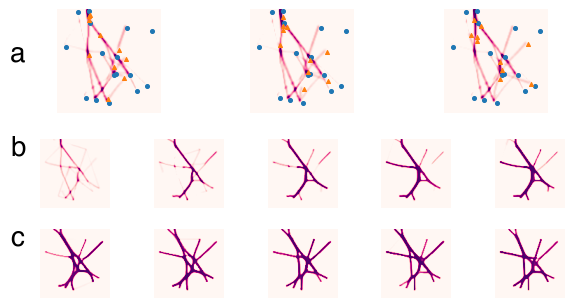

In [34]:
fig = plt.figure(figsize=(two_column_width, 80/mm_to_inch))

subfigs = fig.subfigures(3, 1, height_ratios=[3, 2, 2])

add_top_row(subfigs[0])
add_middle_row(subfigs[1])
add_bottom_row(subfigs[2])

add_letter(subfigs[0], 0.1, 0.5, "a")
add_letter(subfigs[1], 0.1, 0.7, "b")
add_letter(subfigs[2], 0.1, 0.7, "c")

fig.savefig("figures/2.pdf")
fig.savefig("figures/2.svg")